# 01 — Разведочный анализ данных (EDA)

**Проект:** Предсказание уровня среднедушевого дохода домохозяйств Тульской области  
**Данные:** Микроданные выборочного наблюдения доходов населения, 2023 год  
**Регион:** Тульская область (код 71)  
**Целевая переменная:** `doxodn` — среднедушевой доход домохозяйства

## 0. Настройка окружения

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    load_raw_data,
    filter_region,
    create_binary_target,
    FEATURES,
    TARGET_REG,
    REGION_CODE,
)

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)

## 1. Загрузка данных

In [2]:
raw = load_raw_data("../data/raw/Доходы домохозяйств_2023.xlsx")
print(f"Размер исходного датасета: {raw.shape}")
print(f"Регионы в данных (ter): {sorted(raw['ter'].unique()[:10])} ...")
raw.head(3)

Размер исходного датасета: (193256, 42)
Регионы в данных (ter): [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(14)] ...


,per,ter,mest,bud,chlico,chlicn,chisl,chdet,chisd,doxodsn,doxodn,rasress,rasres,rassq,rasq,potras,prod,pitres,alk,neprod,uslug,prompot,nalog,drras,denras,fakt,ssber,rsber,natdox,naldet3,naldet23,tips,msem,mngd,nps,dhpens,dhinv,dhsinv,dhsdinv,chrab,kvzv,decilrfed
0,41,1,1,1188,3,3,3,1,1,143317.67,47772.56,146032.60,48677.53,128997.66,42999.22,126282.93,77571.93,0.0,1542.57,14186.23,32982.20,1309.94,14625.0,600.0,142817.67,500.0,500.0,0,2714.93,0,0,6,0,0,0,0,0,0,0,2,411.219298,3
1,41,1,1,1189,1,1,1,0,5,73393.72,73393.72,74000.12,74000.12,66797.11,66797.11,66190.70,38405.43,0.0,2892.92,3702.66,21189.69,953.01,5850.0,0.0,72993.72,400.0,400.0,0,606.40,0,0,1,0,0,0,0,0,0,0,1,477.251710,5
2,41,1,1,1190,1,1,1,0,5,87920.64,87920.64,88647.22,88647.22,79220.84,79220.84,78494.25,44686.37,0.0,4894.78,3724.36,25188.73,1126.38,7800.0,0.0,87420.64,500.0,500.0,0,726.58,0,0,1,0,0,0,0,0,0,0,1,477.251710,6


In [3]:
df = filter_region(raw, REGION_CODE)
df, q3 = create_binary_target(df)
print(f"Тульская область: {len(df)} домохозяйств")
print(f"Q3 (doxodn): {q3:,.0f} руб.")

Тульская область: 3803 домохозяйств
Q3 (doxodn): 151,407 руб.


## 2. Общая статистика

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
per,3803.0,42.500394,1.118063,4.100000e+01,42.000000,43.000000,43.500000,4.400000e+01
ter,3803.0,71.000000,0.000000,7.100000e+01,71.000000,71.000000,71.000000,7.100000e+01
mest,3803.0,1.210360,0.407618,1.000000e+00,1.000000,1.000000,1.000000,2.000000e+00
bud,3803.0,1857.469629,382.345283,1.188000e+03,1425.000000,1933.000000,2170.500000,4.790000e+03
chlico,3803.0,2.557981,1.179784,1.000000e+00,2.000000,2.000000,3.000000,7.000000e+00
chlicn,3803.0,2.554562,1.176151,1.000000e+00,2.000000,2.000000,3.000000,7.000000e+00
chisl,3803.0,2.546937,1.150712,1.000000e+00,2.000000,2.000000,3.000000,5.000000e+00
chdet,3803.0,0.617144,0.865275,0.000000e+00,0.000000,0.000000,1.000000,5.000000e+00
chisd,3803.0,3.561136,1.778838,1.000000e+00,2.000000,5.000000,5.000000,5.000000e+00
doxodsn,3803.0,275255.572756,254922.334471,8.893000e+01,167669.115000,234768.050000,340591.665000,9.109361e+06


In [5]:
# Пропуски
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"Колонок с пропусками: {len(missing)}")
if len(missing) > 0:
    print(missing)

Колонок с пропусками: 0


## 3. Целевая переменная — doxodn

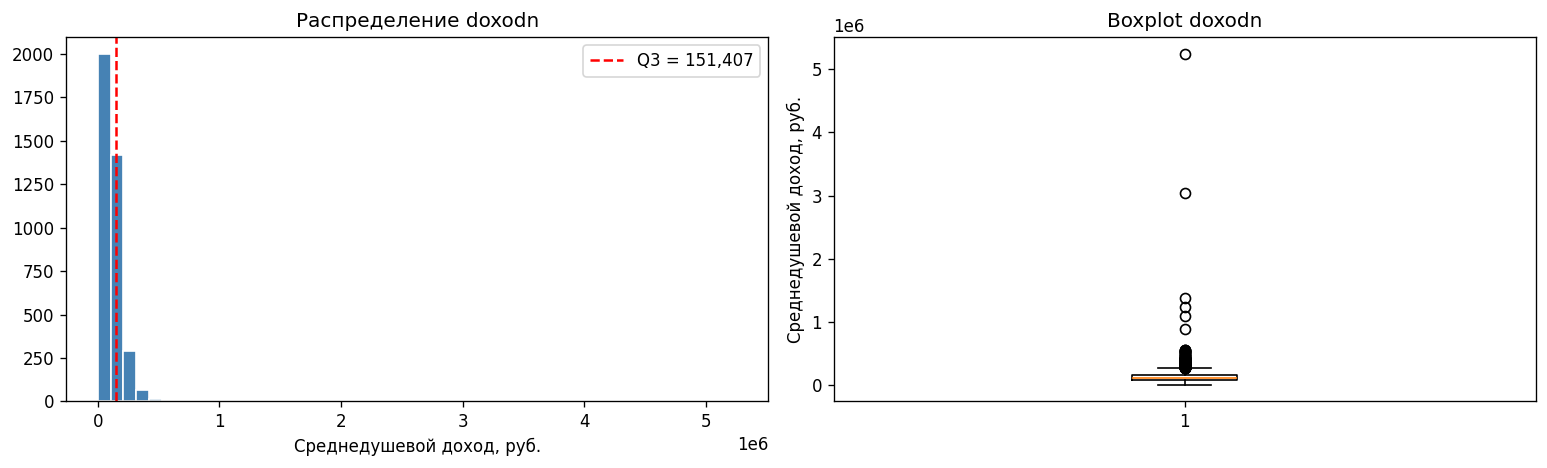

Целевая переменная doxodn:
count       3803.00
mean      123108.11
std       124553.73
min           29.64
25%        69978.20
50%       101097.64
75%       151407.16
max      5250793.40
Name: doxodn, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET_REG].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(q3, color="red", linestyle="--", label=f"Q3 = {q3:,.0f}")
axes[0].set_title("Распределение doxodn")
axes[0].set_xlabel("Среднедушевой доход, руб.")
axes[0].legend()

axes[1].boxplot(df[TARGET_REG].dropna(), vert=True)
axes[1].set_title("Boxplot doxodn")
axes[1].set_ylabel("Среднедушевой доход, руб.")

plt.tight_layout()
plt.savefig("../report/images/eda_target_distribution.png", bbox_inches="tight")
plt.show()

print("Целевая переменная doxodn:")
print(df[TARGET_REG].describe().round(2))

In [7]:
# Баланс классов
counts = df["doxodn_high"].value_counts()
print("Баланс классов (doxodn_high):")
print(counts)
print(f"Доля класса 1 (выше Q3): {counts[1]/len(df)*100:.1f}%")

Баланс классов (doxodn_high):
doxodn_high
0    2852
1     951
Name: count, dtype: int64
Доля класса 1 (выше Q3): 25.0%


## 4. Признаки модели

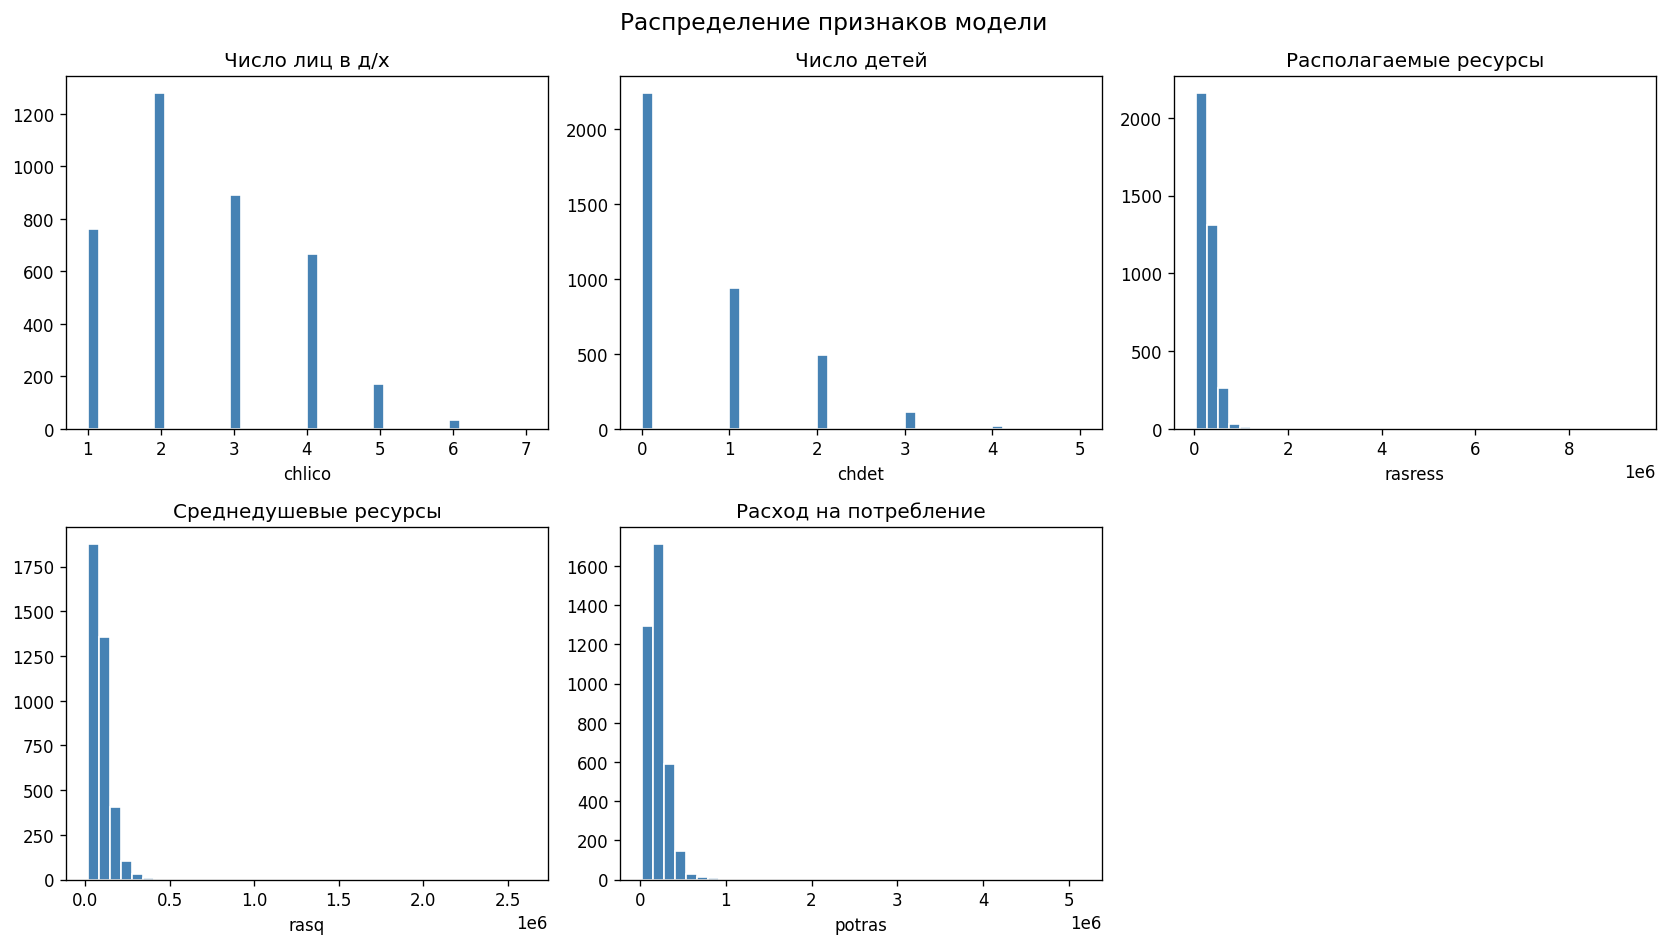

In [8]:
FEATURE_LABELS = {
    "chlico": "Число лиц в д/х",
    "chdet": "Число детей",
    "rasress": "Располагаемые ресурсы",
    "rasq": "Среднедушевые ресурсы",
    "potras": "Расход на потребление",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(df[feat].dropna(), bins=40, color="steelblue", edgecolor="white")
    ax.set_title(FEATURE_LABELS.get(feat, feat))
    ax.set_xlabel(feat)

axes[-1].axis("off")
plt.suptitle("Распределение признаков модели", fontsize=14)
plt.tight_layout()
plt.savefig("../report/images/eda_feature_distributions.png", bbox_inches="tight")
plt.show()

## 5. Матрица корреляций

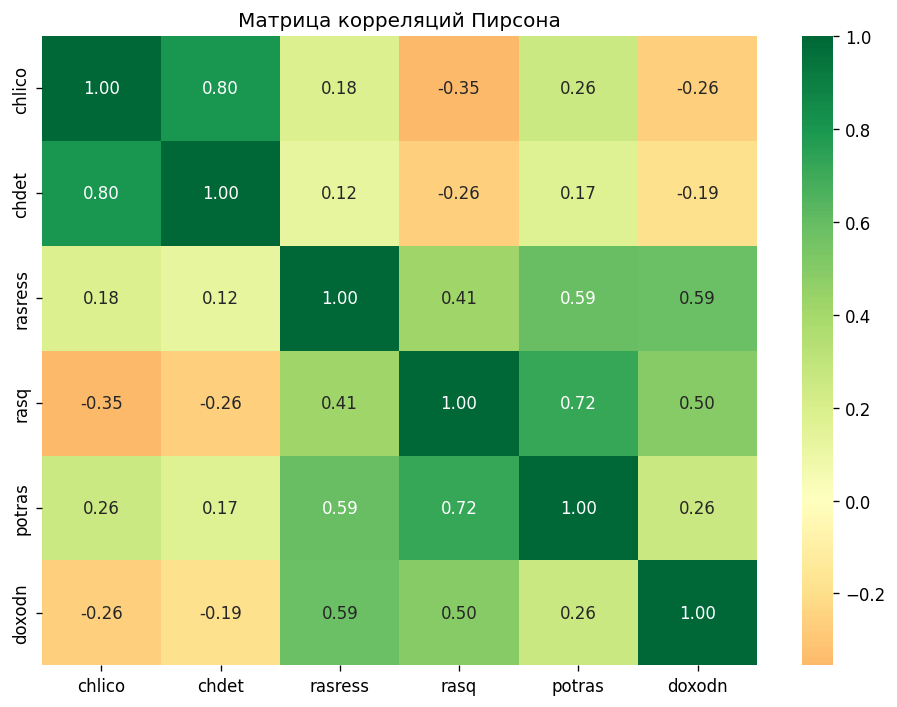

In [9]:
cols = FEATURES + [TARGET_REG]
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            xticklabels=cols, yticklabels=cols)
plt.title("Матрица корреляций Пирсона")
plt.tight_layout()
plt.savefig("../report/images/eda_correlation_matrix.png", bbox_inches="tight")
plt.show()

## 6. Признаки vs целевая переменная

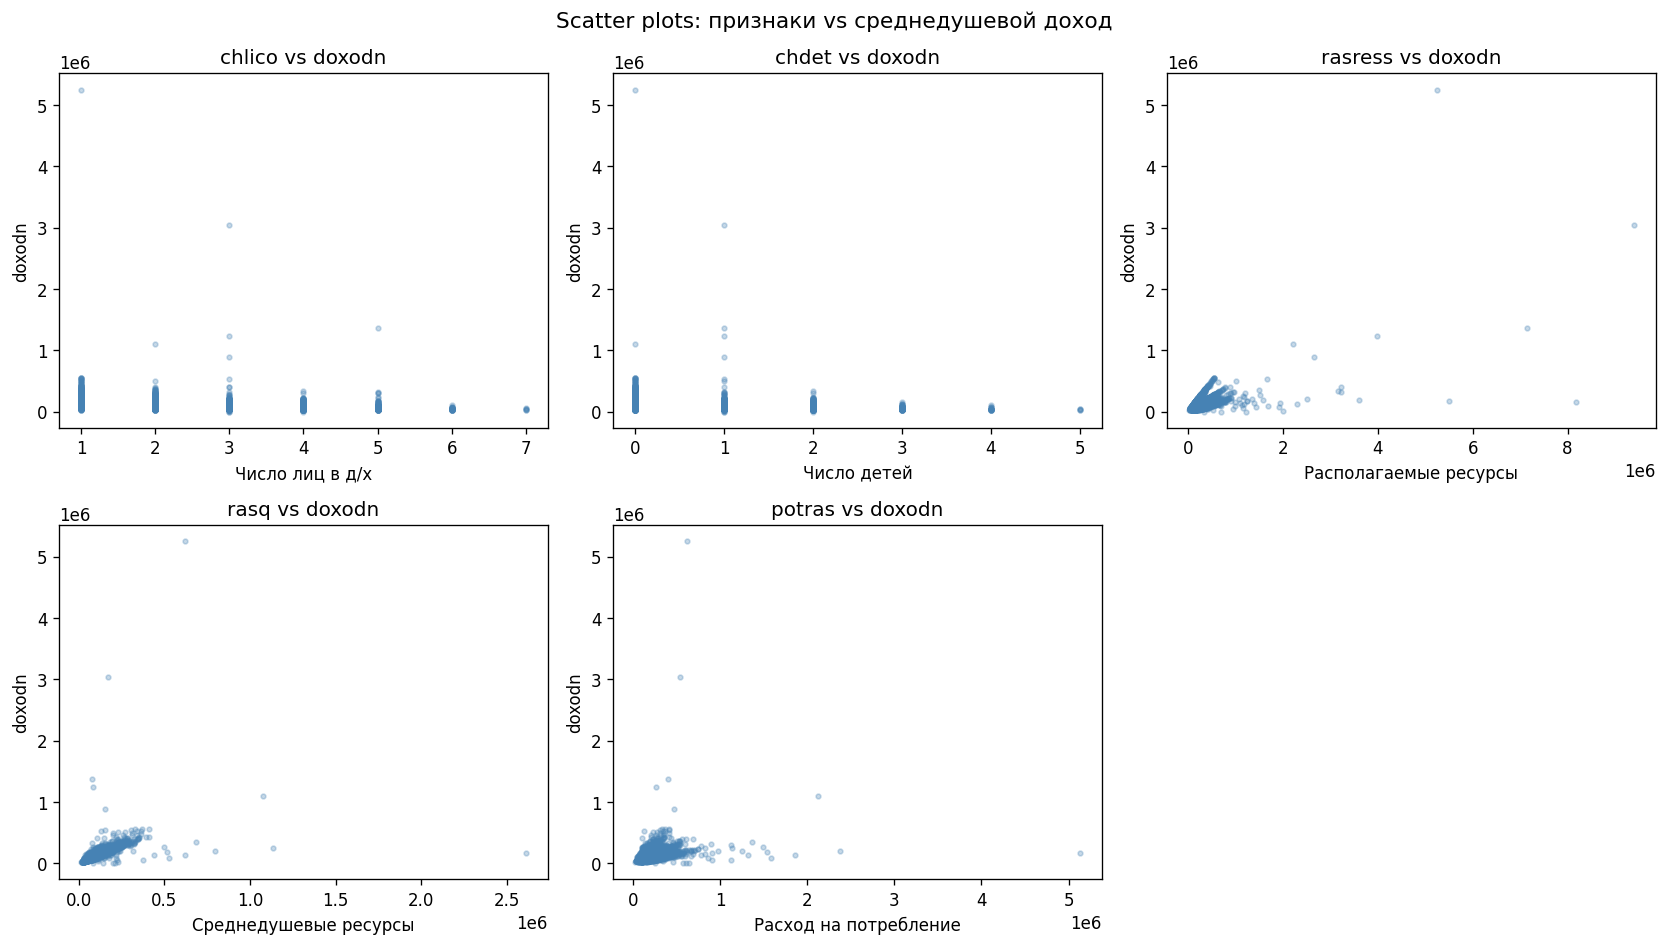

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    df_plot = df[[feat, TARGET_REG]].dropna()
    ax.scatter(df_plot[feat], df_plot[TARGET_REG], alpha=0.3, s=8, color="steelblue")
    ax.set_xlabel(FEATURE_LABELS.get(feat, feat))
    ax.set_ylabel("doxodn")
    ax.set_title(f"{feat} vs doxodn")

axes[-1].axis("off")
plt.suptitle("Scatter plots: признаки vs среднедушевой доход", fontsize=13)
plt.tight_layout()
plt.savefig("../report/images/eda_scatter_plots.png", bbox_inches="tight")
plt.show()

## 7. Распределение по группам (выше/ниже Q3)

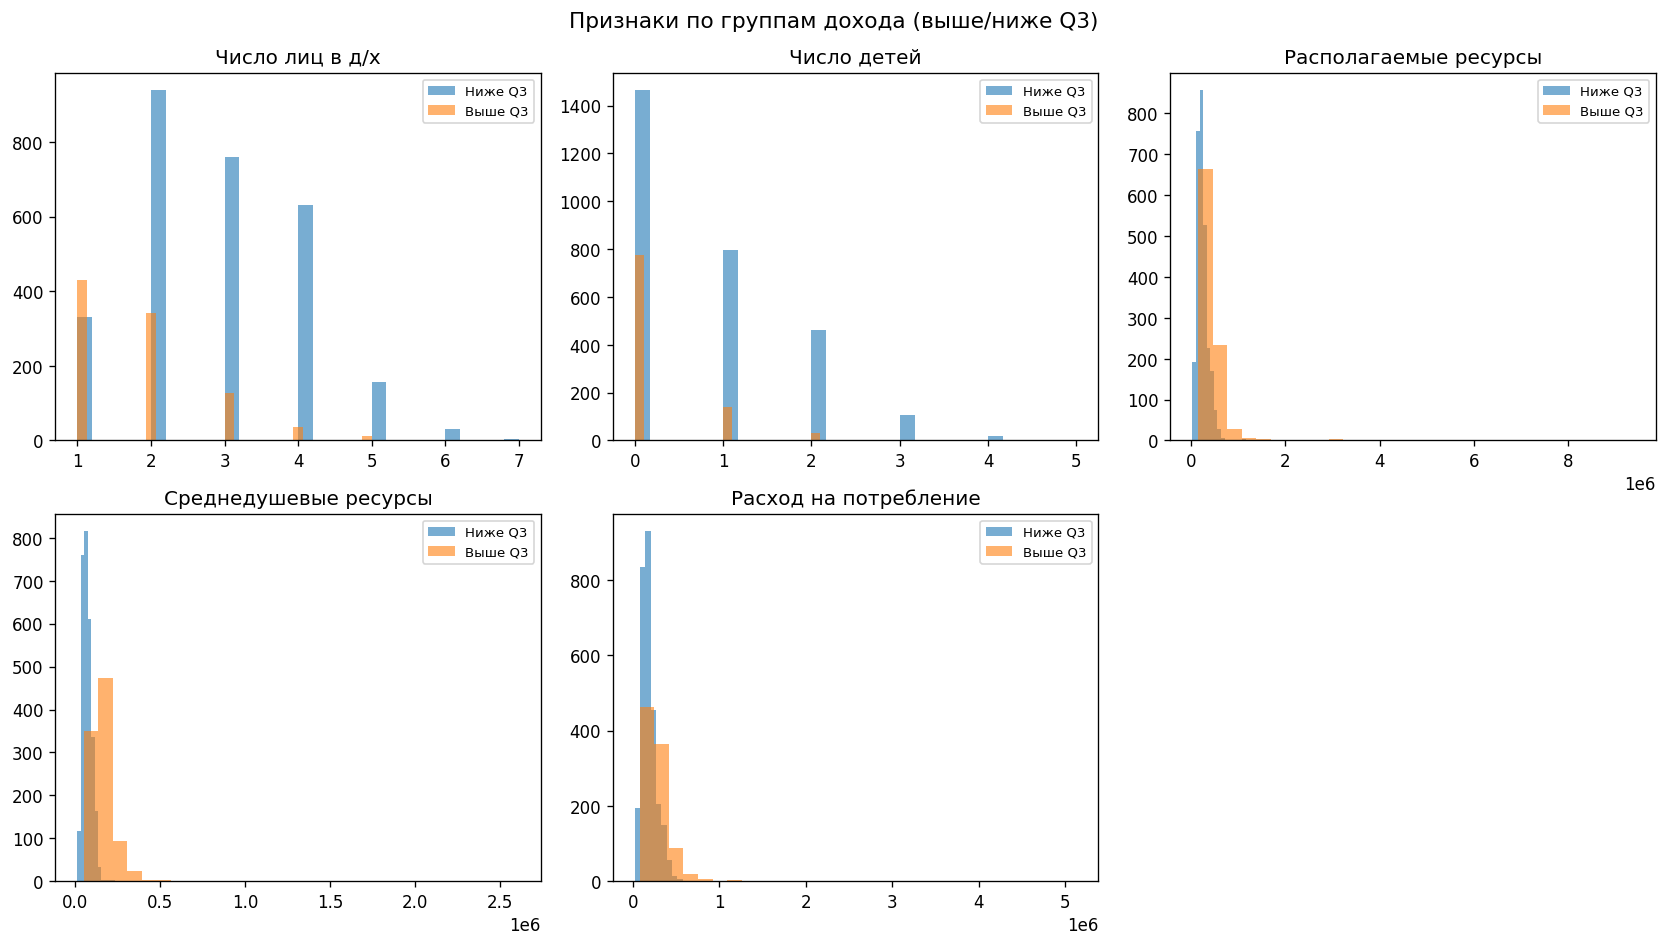

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for label, grp in df.groupby("doxodn_high"):
        name = "Выше Q3" if label == 1 else "Ниже Q3"
        ax.hist(grp[feat].dropna(), bins=30, alpha=0.6, label=name)
    ax.set_title(FEATURE_LABELS.get(feat, feat))
    ax.legend(fontsize=8)

axes[-1].axis("off")
plt.suptitle("Признаки по группам дохода (выше/ниже Q3)", fontsize=13)
plt.tight_layout()
plt.savefig("../report/images/eda_group_distributions.png", bbox_inches="tight")
plt.show()

## 8. Итоги EDA

- В Тульской области **3 803 домохозяйства** с 42 характеристиками.
- Целевая переменная `doxodn` имеет правостороннее распределение; Q3 ≈ 151 400 руб.
- **25% домохозяйств** попадают в группу "выше Q3" (класс 1).
- Наибольшую корреляцию с `doxodn` показывают `rasq` и `rasress`.
- `chlico` и `chdet` отрицательно коррелируют с `doxodn` — больше человек/детей ведёт к снижению среднедушевого дохода.
- Пропусков в анализируемых признаках нет.